# TMDB — Örnek Kullanım

Bu notebook `src/` modüllerinin nasıl kullanıldığını gösterir.
Yeni bir dataset veya task type ile başlamak için yalnızca **Konfigürasyon** hücresini düzenle.

| Adım | Açıklama |
|------|----------|
| 1 | Kütüphaneler & import |
| 2 | Konfigürasyon |
| 3 | Eğitim |
| 4 | Tuning |
| 5 | Test değerlendirmesi |
| 6 | Rapor |

## 1 — Kütüphaneler

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import mlflow
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

from src.modeling import MAIN_METRIC, train_session, compare_models
from src.evaluation import evaluate_test
from src.tuning import tune_model
from src.reporting import generate_experiment_report

RANDOM_STATE = 42
print('✓ Hazır')

✓ Hazır


## 2 — Konfigürasyon

In [2]:
# ── Yeni bir proje için yalnızca bu hücreyi düzenle ───────────
DATASET_PATH     = 'data/tmdb_model.csv'
TASK_TYPE        = 'binary'   # binary | multiclass | regression | timeseries | multilabel
TARGET           = 'hit'
N_TRIALS         = 50
FEATURE_PREFIXES = ['genre_', 'kw_']  # otomatik genişletilecek sütun ön ekleri

BASE_FEATURES = [
    'budget_log', 'runtime',
    # 'popularity', 'vote_average', 'vote_count',
    'num_companies', 'num_countries', 'num_genres',
    'tagline_length', 'overview_length',
    'is_major_studio', 'is_english', 'is_us_production',
    'has_homepage', 'has_postcredit',
]
# ──────────────────────────────────────────────────────────────

### Veri Hazırlama *(dokunma)*

In [3]:
EXPERIMENT_NAME = Path(DATASET_PATH).stem
MLFLOW_URI = os.getenv('MLFLOW_TRACKING_URI', 'http://localhost:5000')
mlflow.set_tracking_uri(MLFLOW_URI)

df          = pd.read_csv(DATASET_PATH)
prefix_cols = [c for c in df.columns if any(c.startswith(p) for p in FEATURE_PREFIXES)]
FEATURES    = BASE_FEATURES + prefix_cols

df_model = df[FEATURES + [TARGET]].dropna()
X        = df_model[FEATURES]
y        = df_model[TARGET]

if TASK_TYPE == 'timeseries':
    split_idx = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
else:
    stratify = y if TASK_TYPE in ('binary', 'multiclass') else None
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=stratify, random_state=RANDOM_STATE
    )

print(f'Dataset  : {DATASET_PATH}')
print(f'Task     : {TASK_TYPE}')
print(f'Toplam   : {len(df_model):,}  |  hit oranı: %{y.mean()*100:.1f}')
print(f'Train    : {len(X_train):,}')
print(f'Test     : {len(X_test):,}')
print(f'Özellik  : {len(FEATURES)}')

Dataset  : data/tmdb_model.csv
Task     : binary
Toplam   : 3,226  |  hit oranı: %34.8
Train    : 2,580
Test     : 646
Özellik  : 49


## 3 — Baseline Eğitimi

Eğitim başlıyor  —  experiment: "tmdb_model"  |  oturum: session_A_20260415_1936  |  task: binary


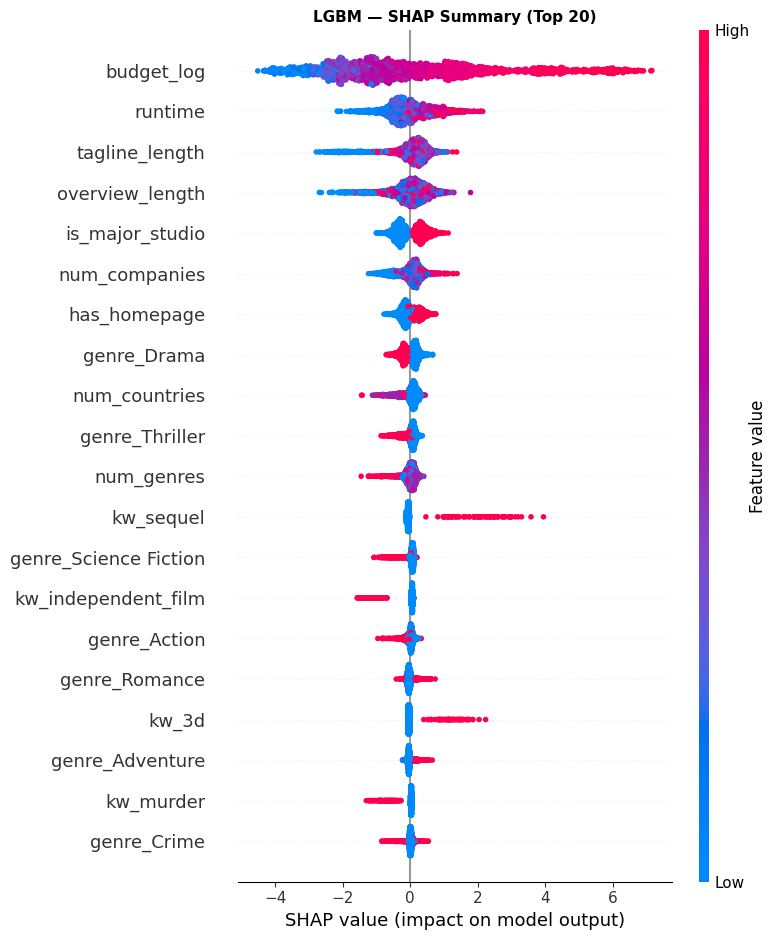

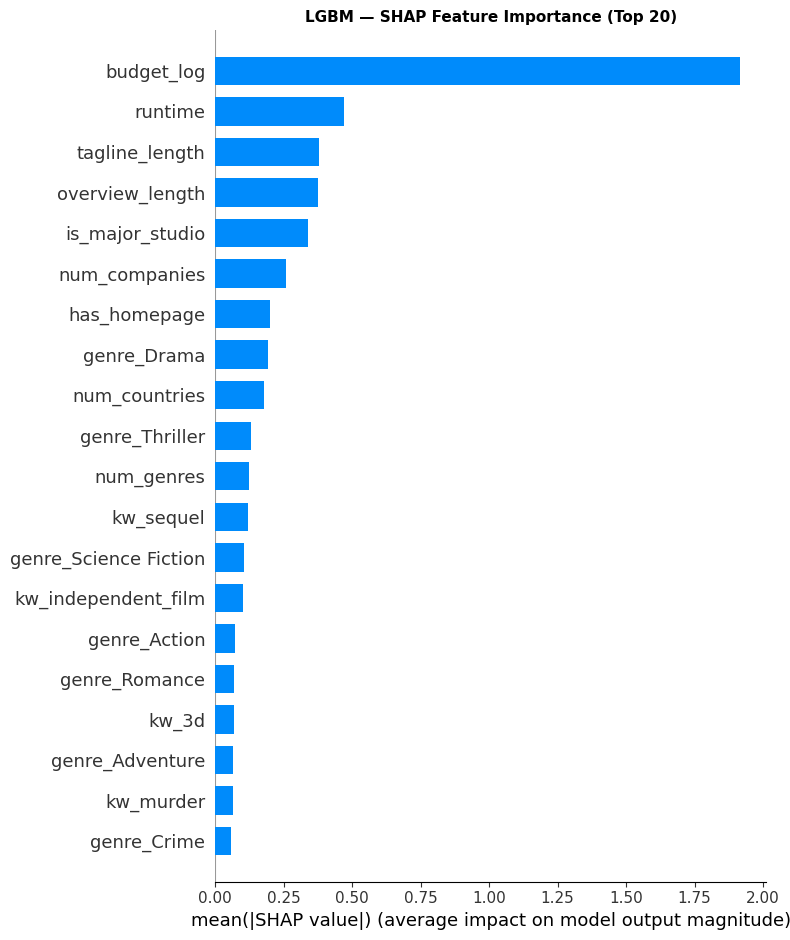

2026/04/15 19:36:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/15 19:36:41 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  ✓ baseline_lgbm_20260415_1936                        train=1.000  val=0.754  gap=+0.246
🏃 View run baseline_lgbm_20260415_1936 at: http://localhost:5000/#/experiments/1/runs/28b5b4f3c93a463c8b7b13ca9a2207e8
🧪 View experiment at: http://localhost:5000/#/experiments/1


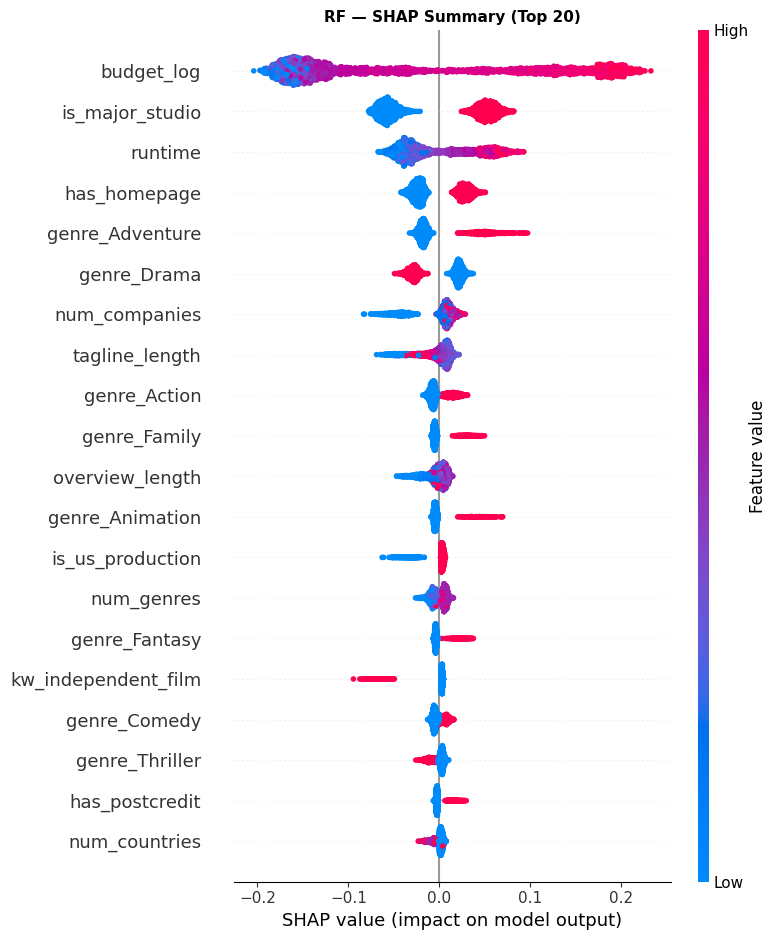

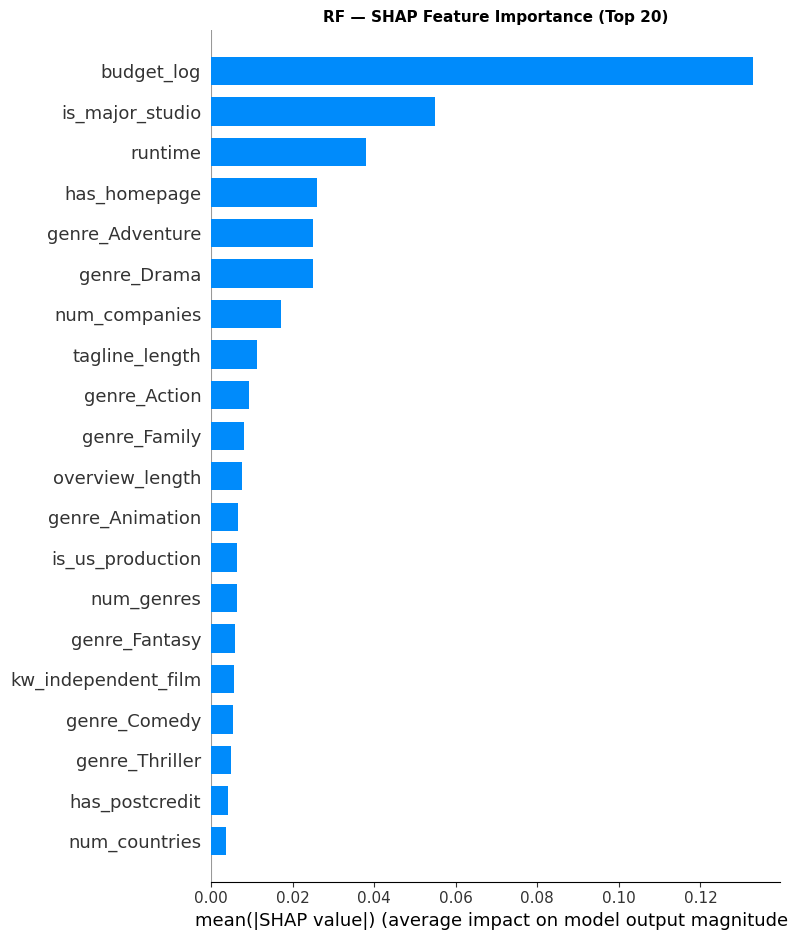

2026/04/15 19:36:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/15 19:36:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  ✓ baseline_rf_20260415_1936                          train=0.857  val=0.785  gap=+0.073
🏃 View run baseline_rf_20260415_1936 at: http://localhost:5000/#/experiments/1/runs/85af6098ce6948a6a6f888c6114d7ec7
🧪 View experiment at: http://localhost:5000/#/experiments/1


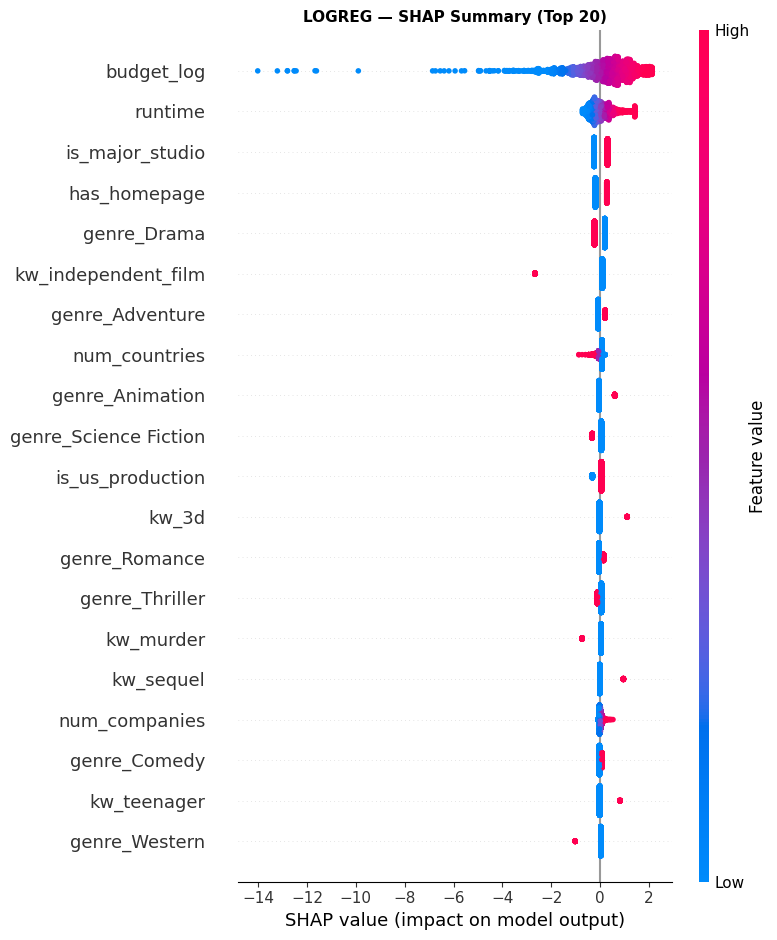

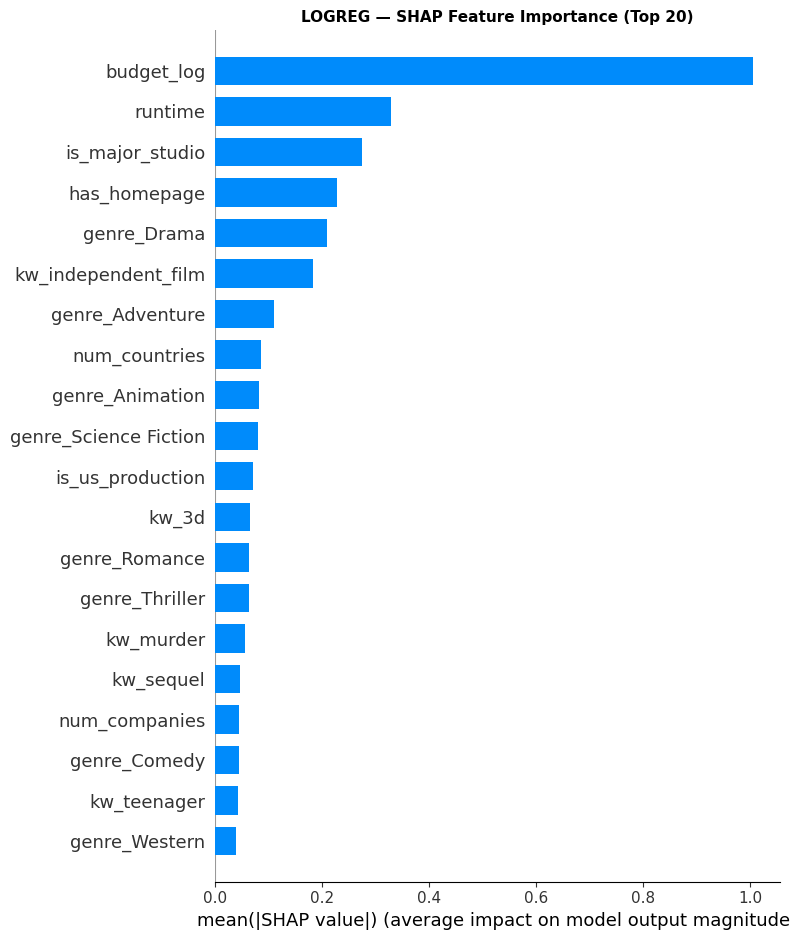

2026/04/15 19:37:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/15 19:37:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  ✓ baseline_logreg_20260415_1937                      train=0.791  val=0.762  gap=+0.029
🏃 View run baseline_logreg_20260415_1937 at: http://localhost:5000/#/experiments/1/runs/d704d3a2f2344a158f7058cbfee2a5aa
🧪 View experiment at: http://localhost:5000/#/experiments/1
🏃 View run session_A_20260415_1936 at: http://localhost:5000/#/experiments/1/runs/844b4887af84480f80f2a41bc62dbc4a
🧪 View experiment at: http://localhost:5000/#/experiments/1

✓ Oturum tamamlandı


In [4]:
MODEL_CONFIGS = {
    'lgbm': lambda ir: LGBMClassifier(
        n_estimators=400, learning_rate=0.05, num_leaves=31,
        min_child_samples=20, scale_pos_weight=ir,
        random_state=RANDOM_STATE, verbose=-1, n_jobs=1,
    ),
    'rf': lambda ir: RandomForestClassifier(
        n_estimators=300, max_depth=10, min_samples_leaf=10,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=1,
    ),
    'logreg': lambda ir: Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            C=0.1, class_weight='balanced',
            max_iter=1000, random_state=RANDOM_STATE,
        )),
    ]),
}

models, results = train_session(
    DATASET_PATH, MODEL_CONFIGS, X_train, y_train,
    task_type=TASK_TYPE, scenario='A',
)

=== Model Karşılaştırma Tablosu ===


,ROC_AUC,F1,PRECISION,RECALL,AVG_PREC
Model,,,,,
lgbm,0.828,0.654,0.704,0.612,0.754
rf,0.851,0.692,0.667,0.719,0.785
logreg,0.837,0.681,0.621,0.754,0.762



🏆 En iyi model: rf  (avg_prec=0.785)
🏃 View run comparison_chart at: http://localhost:5000/#/experiments/1/runs/9d2734eee76441adbb8c9204c7c79572
🧪 View experiment at: http://localhost:5000/#/experiments/1


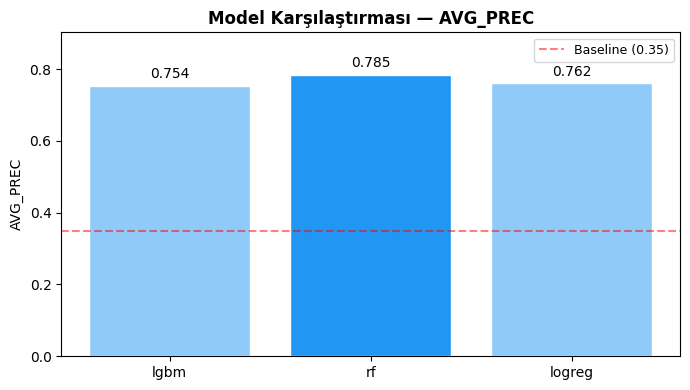


=== Overfitting / Underfitting Analizi ===


,Train AVG_PREC,Val AVG_PREC,Gap (Train−Val)
Model,,,
lgbm,1.000,0.754,0.246
rf,0.857,0.785,0.073
logreg,0.791,0.762,0.029


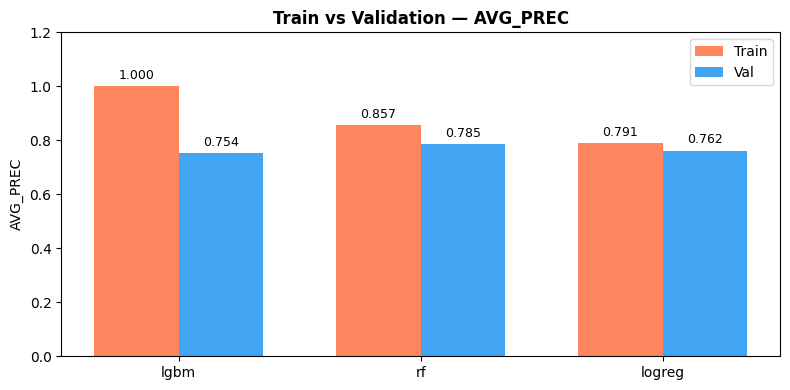

  ⚠️  lgbm: ciddi overfit (gap=0.246 > 0.2) — dışlandı
  ✓ Geçerli modeller: ['rf', 'logreg'] — en iyi: rf


In [ ]:
main_metric = MAIN_METRIC[TASK_TYPE]
best        = compare_models(results, TASK_TYPE, EXPERIMENT_NAME, y_train)
best_model  = models[best]

## 4 — Hiperparametre Tuning

In [6]:
best_model, study = tune_model(
    model_name     = best,
    X              = X_train,
    y              = y_train,
    task_type      = TASK_TYPE,
    baseline_score = results[best]['val'][main_metric],
    n_trials       = N_TRIALS,
)

Optuna başlıyor — model: rf  |  metrik: avg_prec  |  trial: 50


  0%|          | 0/50 [00:00<?, ?it/s]


✓ Tuning tamamlandı
  Baseline  avg_prec: 0.7847
  Tuned     avg_prec: 0.7884
  İyileşme : +0.0037

  En iyi parametreler:
    n_estimators: 254
    max_depth: 15
    min_samples_leaf: 6
    max_features: sqrt


2026/04/15 19:38:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/15 19:38:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✓ Tuning sonuçları ve model MLflow'a kaydedildi
🏃 View run tuning_rf_20260415_1938 at: http://localhost:5000/#/experiments/1/runs/9f4694c8656f408b8113c94ba14d7049
🧪 View experiment at: http://localhost:5000/#/experiments/1

✓ best_model güncellendi — tuned rf


## 5 — Test Değerlendirmesi

              precision    recall  f1-score   support

           0       0.85      0.86      0.86       421
           1       0.74      0.72      0.73       225

    accuracy                           0.81       646
   macro avg       0.79      0.79      0.79       646
weighted avg       0.81      0.81      0.81       646


=== Test Metrikleri ===
  PR-AUC      : 0.8092
  ROC-AUC     : 0.8752
  F1          : 0.7252
  Precision   : 0.7352
  Recall      : 0.7156

=== RF — CV vs Test Karşılaştırması ===


,CV (val),Test,Fark
PR-AUC,0.785,0.809,0.024
ROC-AUC,0.851,0.875,0.024
F1,0.692,0.725,0.033
Precision,0.667,0.735,0.068
Recall,0.719,0.716,-0.003


🏃 View run test_eval_rf_20260415_1938 at: http://localhost:5000/#/experiments/1/runs/5da63c56131f40be837b07fa489cdc35
🧪 View experiment at: http://localhost:5000/#/experiments/1
✓ Test metrikleri MLflow'a kaydedildi


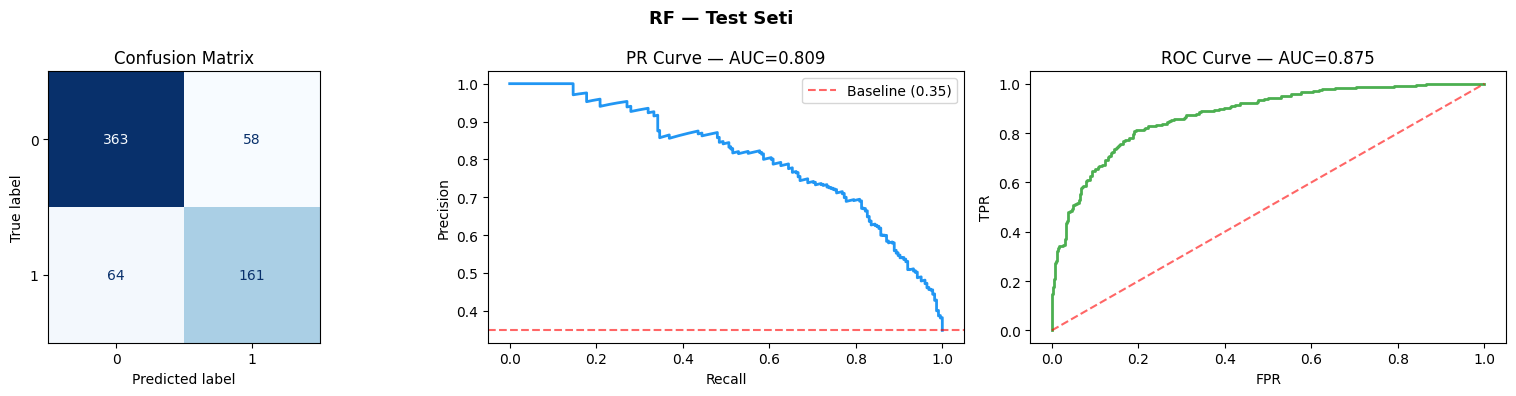

In [7]:
test_metrics = evaluate_test(
    best_model, X_test, y_test, TASK_TYPE, best,
    cv_metrics      = results[best]['val'],
    experiment_name = EXPERIMENT_NAME,
)


## 6 — Rapor

In [8]:
report = generate_experiment_report(
    experiment_name = EXPERIMENT_NAME,
    task_type       = TASK_TYPE,
    dataset_path    = DATASET_PATH,
    n_samples       = len(df_model),
    hit_rate        = y.mean(),
    n_features      = len(FEATURES),
)

print(report)

✓ Rapor oluşturuldu → experiment_report_20260415_193831.md
✓ MLflow'a kaydedildi → docs/experiment_report_20260415_193831.md
🏃 View run report_20260415_1938 at: http://localhost:5000/#/experiments/1/runs/f8604c784f234d8281eda9eda19b02b2
🧪 View experiment at: http://localhost:5000/#/experiments/1
# Experiment Raporu — tmdb_model

**Oluşturulma:** 2026-04-15 19:38  
**Task:** binary  
**Ana Metrik:** avg_prec  
**Dataset:** data/tmdb_model.csv  
**Toplam Film:** 3,226  |  **Hit Oranı:** %34.8  
**Özellik Sayısı:** 49  

---

## Baseline Sonuçları

| Model | PR-AUC | ROC-AUC | F1 | Precision | Recall |
|-------|--------|---------|----|-----------|----|
| lgbm | 0.869 | 0.915 | 0.767 | 0.794 | 0.742 |
| rf | 0.869 | 0.916 | 0.773 | 0.725 | 0.828 |
| logreg | 0.844 | 0.898 | 0.756 | 0.721 | 0.794 |
| lgbm | 0.754 | 0.828 | 0.654 | 0.704 | 0.612 |
| rf | 0.785 | 0.851 | 0.692 | 0.667 | 0.719 |
| logreg | 0.762 | 0.837 | 0.681 | 0.621 | 0.754 |
| lgbm | 0.754 | 0.828 | 0.654 | 0.704 | 0.612 |

## 7 — Hibrit Modeller

Baseline modellerin (LGBM, RF, LogReg) güçlü yönlerini birleştirmek için üç strateji deneniyor.

| Yöntem | Fikir | Artısı | Eksi |
|--------|-------|--------|------|
| **Voting** | Olasılıkların ağırlıklı ortalaması | Basit, hızlı, yorumlanabilir | Modeller aynı hatayı paylaşabilir |
| **Stacking** | CV ile out-of-fold meta-özellik → meta-model | En güçlü kombinasyon | Yavaş, dikkatli CV gerektirir |
| **Blending** | Holdout meta-özellik → meta-model (CV yok) | Hızlı, leakage riski düşük | Daha az veri verimli |

In [ ]:
import numpy as np
from sklearn.ensemble import VotingClassifier, StackingClassifier

ir = int((y_train == 0).sum() / (y_train == 1).sum())

def make_lgbm():
    return LGBMClassifier(
        n_estimators=400, learning_rate=0.05, num_leaves=31,
        min_child_samples=20, scale_pos_weight=ir,
        random_state=RANDOM_STATE, verbose=-1, n_jobs=1,
    )

def make_rf():
    return RandomForestClassifier(
        n_estimators=300, max_depth=10, min_samples_leaf=10,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=1,
    )

def make_logreg():
    return Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            C=0.1, class_weight='balanced',
            max_iter=1000, random_state=RANDOM_STATE,
        )),
    ])

print(f'✓ Base model factory hazır  |  imbalance_ratio: {ir}')

### 7a — Voting Ensemble

`VotingClassifier(voting='soft')` her modelin olasılık tahminlerini ağırlıklı ortalamayla birleştirir.
LGBM baseline'da en güçlü performansı gösterdiği için `weights=[2, 1, 1]` kullanıyoruz.

In [ ]:
voting_clf = VotingClassifier(
    estimators=[
        ('lgbm',   make_lgbm()),
        ('rf',     make_rf()),
        ('logreg', make_logreg()),
    ],
    voting='soft',
    weights=[2, 1, 1],  # LGBM baseline'da en güçlü → daha yüksek ağırlık
    n_jobs=1,
)
voting_clf.fit(X_train, y_train)

voting_metrics = evaluate_test(
    voting_clf, X_test, y_test, TASK_TYPE, 'voting_ensemble',
    cv_metrics=results[best]['val'],
    experiment_name=EXPERIMENT_NAME,
)

### 7b — Stacking

`StackingClassifier` her base modeli 5-fold CV ile eğitip out-of-fold tahminlerini
meta-özellik olarak kullanır. Meta-model (LogisticRegression) bu özelliklerden öğrenir.

In [ ]:
stacking_clf = StackingClassifier(
    estimators=[
        ('lgbm', make_lgbm()),
        ('rf',   make_rf()),
    ],
    final_estimator=LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE),
    cv=5,
    stack_method='predict_proba',
    passthrough=False,
    n_jobs=1,
)
stacking_clf.fit(X_train, y_train)

stacking_metrics = evaluate_test(
    stacking_clf, X_test, y_test, TASK_TYPE, 'stacking',
    cv_metrics=results[best]['val'],
    experiment_name=EXPERIMENT_NAME,
)

### 7c — Blending

Train setinin %20'si **holdout** olarak ayrılır. Base modeller kalan %80 üzerinde eğitilir;
holdout tahminleri meta-model için girdi oluşturur. Stacking'e kıyasla daha hızlı ama
daha az veri verimlidir.

In [ ]:
class BlendingEnsemble:
    """
    Blending stratejisi:
      1. X_train → blend_train (%80) + holdout (%20) olarak bölünür.
      2. Base modeller yalnızca blend_train üzerinde eğitilir.
      3. Holdout tahminleri (predict_proba) meta-özellik matrisini oluşturur.
      4. Meta-model bu matris üzerinde eğitilir.
      5. Test tahminleri: base modeller test setini tahmin eder → meta-model birleştirir.

    Stacking'den farkı: CV yoktur; bilgi sızıntısını önlemek için ayrı bir holdout kullanılır.
    """

    def __init__(self, base_models: list, meta_model, blend_ratio: float = 0.2,
                 random_state: int = 42):
        self.base_models  = base_models   # [(isim, estimator), ...]
        self.meta_model   = meta_model
        self.blend_ratio  = blend_ratio
        self.random_state = random_state

    def fit(self, X, y):
        from sklearn.model_selection import train_test_split
        X_bt, X_hold, y_bt, y_hold = train_test_split(
            X, y,
            test_size=self.blend_ratio,
            stratify=y,
            random_state=self.random_state,
        )
        for _, m in self.base_models:
            m.fit(X_bt, y_bt)

        meta_train = np.column_stack([
            m.predict_proba(X_hold)[:, 1] for _, m in self.base_models
        ])
        self.meta_model.fit(meta_train, y_hold)
        return self

    def predict_proba(self, X):
        meta = np.column_stack([
            m.predict_proba(X)[:, 1] for _, m in self.base_models
        ])
        prob1 = self.meta_model.predict_proba(meta)[:, 1]
        return np.column_stack([1 - prob1, prob1])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

print('✓ BlendingEnsemble sınıfı tanımlandı')

In [ ]:
blending_clf = BlendingEnsemble(
    base_models=[
        ('lgbm',   make_lgbm()),
        ('rf',     make_rf()),
        ('logreg', make_logreg()),
    ],
    meta_model=LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE),
    blend_ratio=0.2,
    random_state=RANDOM_STATE,
)
blending_clf.fit(X_train, y_train)

blending_metrics = evaluate_test(
    blending_clf, X_test, y_test, TASK_TYPE, 'blending',
    cv_metrics=results[best]['val'],
    experiment_name=EXPERIMENT_NAME,
)

### Tüm Hibrit Modellerin Karşılaştırması

In [ ]:
metric_col = 'PR-AUC'
hybrid_results = {
    f'best_single ({best})': test_metrics,
    'voting':                voting_metrics,
    'stacking':              stacking_metrics,
    'blending':              blending_metrics,
}

rows = []
for name, m in hybrid_results.items():
    rows.append({'Model': name, **{k: round(v, 4) for k, v in m.items()}})
comparison_df = pd.DataFrame(rows).set_index('Model')
print('=== Hibrit Model Karşılaştırması ===')
display(comparison_df)

vals   = [m.get(metric_col, 0) for m in hybrid_results.values()]
labels = list(hybrid_results.keys())
colors = ['#90CAF9', '#2196F3', '#4CAF50', '#FF7043']

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(labels, vals, color=colors, edgecolor='white')
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=10)
ax.set_title(f'Hibrit Model Karşılaştırması — {metric_col}', fontsize=12, fontweight='bold')
ax.set_ylim(0, max(vals) * 1.15)
ax.set_ylabel(metric_col)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()